<a href="https://colab.research.google.com/github/AvirupVIP/SIGNIFY---Signature-Forgery-Detection-System/blob/master/MobileNet_V3(_another_larger_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
!pip install opencv-python
!pip install scikit-learn

In [ ]:
import os
import json

kaggle_config = {
  "username":"sandandipto",
  "key":"KGAT_d5a3d64f806d070d376a3862e1c6f371"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tienen/handwritten-signature-verification

Dataset URL: https://www.kaggle.com/datasets/tienen/handwritten-signature-verification
License(s): CC0-1.0
100% 2.10G/2.10G [00:36<00:00, 200MB/s]
100% 2.10G/2.10G [00:36<00:00, 61.4MB/s]


In [ ]:
!unzip handwritten-signature-verification.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/3__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/4__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/5__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/6__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/7__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/8__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_1644079620406_1_JPEG_20220205_194642.jpg/9__lid_1644079620406_1_JPEG_20220205_194642.jpg.jpg  
  inflating: data/data/forged/lid_164407963803

In [ ]:
!ls

assignments_07-02-2022.tsv  handwritten-signature-verification.zip
data			    sample_data


In [ ]:
!ls data

data


In [ ]:
!ls data/data

forged	real


In [ ]:
!ls data/data/* | head

data/data/forged:
0_sign_forge_31531273_06-02-2022.csv
1140762B-8D0C-4456-A290-63A82666C69E.jpg
2022-02-04 21.42.30.jpg
20220206_125301.jpg
20220206_210359-1.jpg
2AD91C78-31E2-4223-9190-856F666CBD87.jpg
52F192AB-A654-4778-861A-C81E555D4656.jpg
544D5602-9E64-4951-BE1E-6018107929AD.jpg
EE378620-A6F9-488E-8330-883059D43C25.jpg


In [ ]:
!ls /content/data/data

forged	real


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

In [ ]:
dataset_path = "/content/data/data"

genuine_path = os.path.join(dataset_path,"real")
forged_path = os.path.join(dataset_path,"forged")

print("Genuine signatures:",len(os.listdir(genuine_path)))
print("Forged signatures:",len(os.listdir(forged_path)))


Genuine signatures: 549
Forged signatures: 502


In [ ]:
IMG_SIZE = 224

def preprocess_signature(img_path):

    img = cv2.imread(img_path)

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _,thresh = cv2.threshold(
        gray,0,255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    resized = cv2.resize(thresh,(IMG_SIZE,IMG_SIZE))

    normalized = resized/255.0

    normalized = np.expand_dims(normalized,axis=-1)

    normalized = np.repeat(normalized,3,axis=-1)

    return normalized

In [ ]:
genuine_images=[]
forged_images=[]

print("Processing Genuine Signatures")

for img in tqdm(os.listdir(genuine_path)):

    if img.endswith((".png",".jpg",".jpeg")):

        path=os.path.join(genuine_path,img)

        image=preprocess_signature(path)

        if image is not None:
            genuine_images.append(image)

print("Processing Forged Signatures")

for img in tqdm(os.listdir(forged_path)):

    if img.endswith((".png",".jpg",".jpeg")):

        path=os.path.join(forged_path,img)

        image=preprocess_signature(path)

        if image is not None:
            forged_images.append(image)

genuine_images=np.array(genuine_images)
forged_images=np.array(forged_images)

print("Genuine shape:",genuine_images.shape)
print("Forged shape:",forged_images.shape)

Processing Genuine Signatures


100%|██████████| 549/549 [00:35<00:00, 15.49it/s]


Processing Forged Signatures


100%|██████████| 502/502 [00:30<00:00, 16.55it/s]


Genuine shape: (275, 224, 224, 3)
Forged shape: (248, 224, 224, 3)


In [ ]:
pairs=[]
labels=[]

# genuine pairs
for i in range(len(genuine_images)-1):

    pairs.append([genuine_images[i],genuine_images[i+1]])
    labels.append(1)

# forged pairs
for i in range(min(len(genuine_images),len(forged_images))-1):

    pairs.append([genuine_images[i],forged_images[i]])
    labels.append(0)

pairs=np.array(pairs)
labels=np.array(labels)

print("Total pairs:",pairs.shape)

Total pairs: (521, 2, 224, 224, 3)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    pairs,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256,activation="relu")(x)

x = BatchNormalization()(x)

embedding = Dense(128)(x)

embedding_model = Model(base_model.input,embedding)

embedding_model = Model(base_model.input,embedding)

In [ ]:
import tensorflow.keras.backend as K

def cosine_similarity(vectors):

    x,y = vectors

    x = tf.math.l2_normalize(x,axis=1)
    y = tf.math.l2_normalize(y,axis=1)

    return tf.reduce_sum(x*y,axis=1,keepdims=True)

In [ ]:
input_a = Input((224,224,3))
input_b = Input((224,224,3))

feat_a = embedding_model(input_a)
feat_b = embedding_model(input_b)

similarity = Lambda(cosine_similarity)([feat_a,feat_b])

siamese_model = Model(
    inputs=[input_a,input_b],
    outputs=similarity
)

siamese_model.compile(
    loss="mse",
    optimizer="adam",
    metrics=["accuracy"]
)

siamese_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_3        │ (None, 128)       │  2,619,840 │ input_layer_4[0]… │
│ (Functional)        │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ functional_3[0][… │
│                     │                   │            │ functional_3[1][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 1,567,424 (5.98 MB)

 Non-trainable params: 1,052,416 (4.01 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = siamese_model.fit(

    [X_train[:,0],X_train[:,1]],
    y_train,

    validation_data=(
        [X_test[:,0],X_test[:,1]],
        y_test
    ),

    batch_size=32,
    epochs=25,

    callbacks=[early_stop]
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4839 - loss: 0.5573 - val_accuracy: 0.5905 - val_loss: 0.3029
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.5585 - loss: 0.3605 - val_accuracy: 0.6000 - val_loss: 0.3032
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7413 - loss: 0.1810 - val_accuracy: 0.5810 - val_loss: 0.2972
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8720 - loss: 0.1306 - val_accuracy: 0.5524 - val_loss: 0.2951
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9276 - loss: 0.0951 - val_accuracy: 0.5905 - val_loss: 0.2937
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9745 - loss: 0.0688 - val_accuracy: 0.5810 - val_loss: 0.2976
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9748 - loss: 0.0646 - val_accuracy: 0.6000 - val_loss: 0.2917
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9875 - loss: 0.0501 - val_accuracy: 0.5905

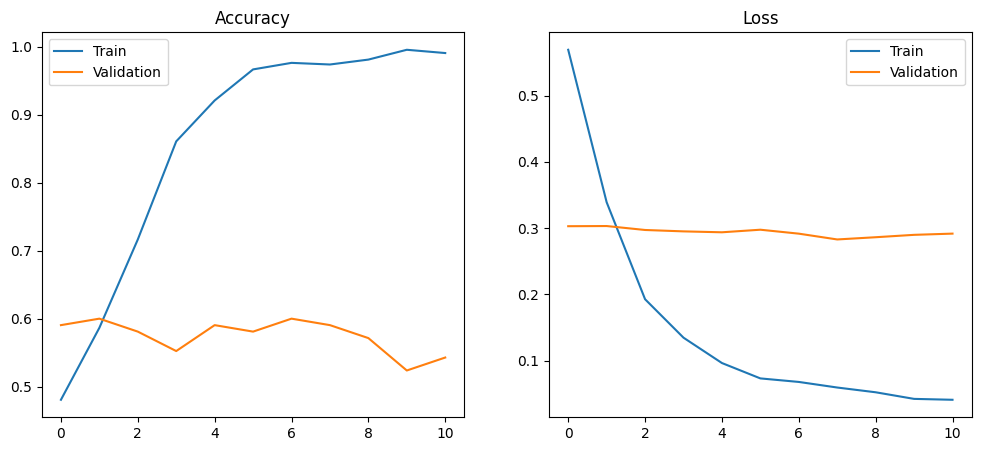

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
def verify_signature(img1_path,img2_path):

    img1 = preprocess_signature(img1_path)
    img2 = preprocess_signature(img2_path)

    img1 = np.expand_dims(img1,axis=0)
    img2 = np.expand_dims(img2,axis=0)

    similarity = siamese_model.predict([img1,img2])[0][0]

    if similarity > 0.7:
        result = "Genuine"
    else:
        result = "Forged"

    print("Prediction:",result)
    print("Similarity Score:",round(float(similarity),3))

In [ ]:
from google.colab import files

uploaded = files.upload()

files_list = list(uploaded.keys())

verify_signature(files_list[0],files_list[1])

Saving Genuine_Sig.jpeg to Genuine_Sig (1).jpeg
Saving Forge_Sig.jpeg to Forge_Sig (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Prediction: Genuine
Similarity Score: 0.892
